In [1]:
import numpy as np
import nibabel as nib
from nilearn import datasets
import os.path as op
import os
import pandas as pd
from brainspace.gradient import GradientMaps
from brainspace.utils.parcellation import map_to_labels
import matplotlib.pyplot as plt

from utils import get_basic_mask
mask, labeling_noParcel = get_basic_mask()
N_vertices = len(np.where(mask==True)[0])

bids_folder = '/mnt_AdaBD_largefiles/Data/SMILE_DATA/DNumRisk/ds-dnumrisk'
ses = 1
task = 'magjudge'

subList = [f'{int(sub):02d}' for sub in range(1, 67)]
from utils import plot_grads


[get_dataset_dir] Dataset found in /home/ubuntu/nilearn_data/destrieux_surface


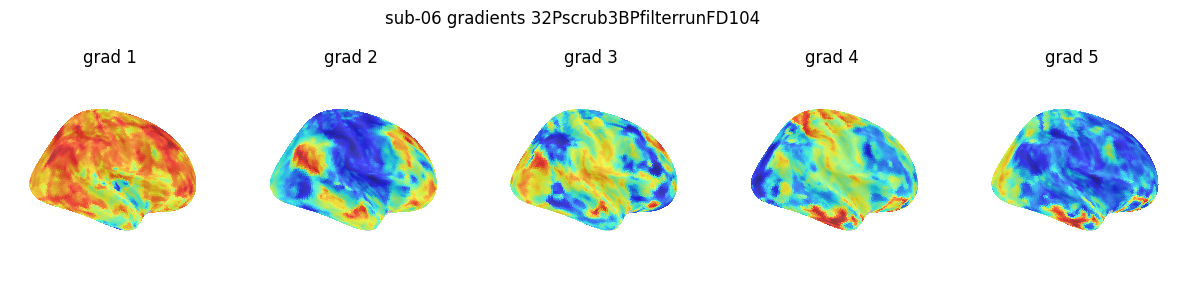

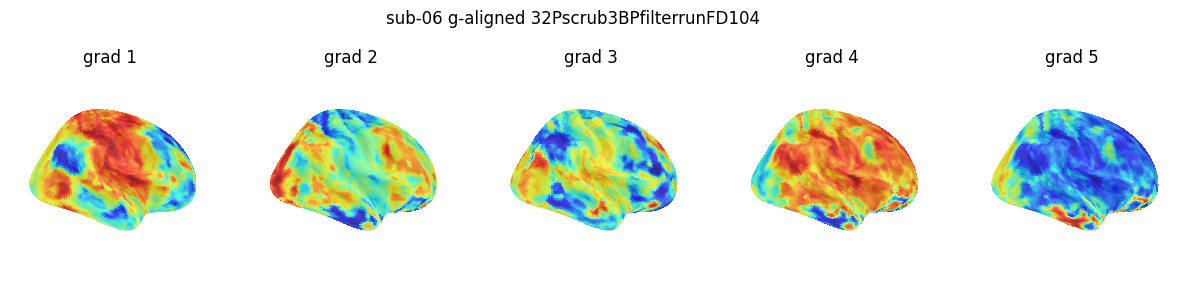

In [2]:
# single sub

sub = '06'
confspec = '32Pscrub3BPfilterrunFD104' # 

spec = 'gradients' # 'g-aligned-margulies16' # 
source_dir = op.join(bids_folder,'derivatives',f'gradients.{confspec}', f'sub-{sub}')
fn = op.join(source_dir, f'sub-{sub}_{spec}_space-fsaverag5_n10.npy')
grad = np.load(fn)
plot_grads(grad, sub, spec=spec, confspec=confspec)

spec = 'g-aligned' #'gradients' # 'g-aligned-margulies16' # 
source_dir = op.join(bids_folder,'derivatives',f'gradients.{confspec}', f'sub-{sub}')
fn = op.join(source_dir, f'sub-{sub}_{spec}_space-fsaverag5_n10.npy')
grad = np.load(fn)
plot_grads(grad, sub, spec=spec, confspec=confspec)

plot_folder = op.join(bids_folder, 'plots_and_ims', f'gradientMaps.{confspec}')
#plt.savefig(op.join(plot_folder, f'sub-{sub}_{spec}_{confspec}_space-fsaverag5_n10.png'), dpi=300)


In [3]:
from utils import get_NPC_mask

# get NPC mask
mask_NPC = get_NPC_mask()

(array([ 69., 120., 118.,  99., 124., 266., 348., 178., 137.,  51.]),
 array([-16.36728625, -12.80469513,  -9.24210401,  -5.67951289,
         -2.11692177,   1.44566935,   5.00826046,   8.57085158,
         12.1334427 ,  15.69603382,  19.25862494]),
 <BarContainer object of 10 artists>)

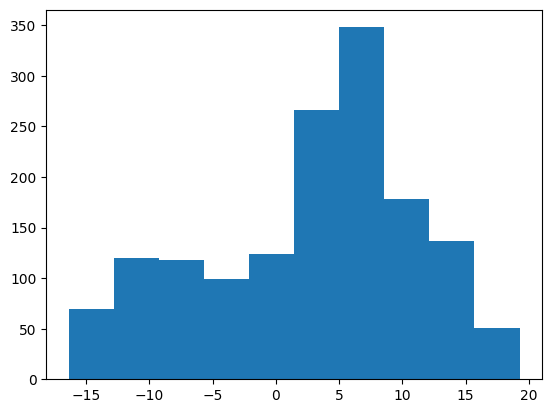

In [4]:
plt.hist(grad[1,mask_NPC])

In [ ]:
# Loop 

confspec = '36Pscrub3BPfilterrunFD104' # 
spec = 'g-aligned' #    'gradients' # 'g-aligned-margulies16' #

plot_folder = op.join(bids_folder, 'plots_and_ims', f'gradientMaps.{confspec}')
if not op.exists(plot_folder):
    os.makedirs(plot_folder)

for sub in subList[47:]:
    source_dir = op.join(bids_folder,'derivatives',f'gradients.{confspec}', f'sub-{sub}')
    fn = op.join(source_dir, f'sub-{sub}_{spec}_space-fsaverag5_n10.npy')
    grad = np.load(fn)
    plot_grads(grad, sub, spec=spec, confspec=confspec)
    plt.savefig(op.join(plot_folder, f'sub-{sub}_{spec}_{confspec}_space-fsaverag5_n10.png'), dpi=300)
    plt.close()


In [7]:
# Old GM different file structure
bids_folder_old ='/mnt_03/ds-dnumrisk'

confspec = 'oldConfounds' # 
spec = 'g-aligned' #'gradients' # 'g-aligned-margulies16' # 

plot_folder = op.join(bids_folder, 'plots_and_ims', f'gradientMaps.{confspec}')
if not op.exists(plot_folder):
    os.makedirs(plot_folder)

for sub in subList:
    source_dir = op.join(bids_folder_old,'derivatives',f'gradients', f'sub-{sub}')
    fn = op.join(source_dir, f'sub-{sub}_{spec}_space-fsaverag5_n10.npy')
    grad = np.load(fn)
    plot_grads(grad, sub, spec=spec, confspec=confspec)
    plt.savefig(op.join(plot_folder, f'sub-{sub}_{spec}_space-fsaverag5_n10.png'), dpi=300)
    plt.close()


# Outlier Subs

- sub-64 : look weird
- sub-06 : [huge NPC dispersion!!]
- sub-30 & 18 - alignment weird... normal gradients - 3 & 4 look very good!; with oldConfounds alignment worked better.,,,.?
